In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, aberration, equatorial2galactic, galactic2equatorial
import os
import numpy as np
import referenceFrames as rf
import matplotlib.pyplot as plt
from math import radians
import h5py
import h5

In [2]:
sim = Simulation("DifferentialStellarAberration")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# We want to cover one year of observations, with one exposure every 5 days

numExposures = 365 * 24 * 60 * 60 // 25
sim["ObservingParameters/NumExposures"] = 1
deltaNumExposures = 24 * 60 * 60 // 25 * 5


starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
dim = 6
sim.createStarCatalogFileFromPixelCoordinates(np.array([100]), np.array([100]), np.array([12.5]), np.array([1]), starCatalogFilename)
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim
sim["SubField/ZeroPointRow"] = 100 - dim // 2
sim["SubField/ZeroPointColumn"] = 100 - dim // 2

# Enable stellar aberration

sim["Camera/IncludeAberrationCorrection"] = "yes"
sim["Camera/AberrationCorrection/Type"] = "differential"

In [4]:
raDiffAbStar = np.array([])
decDiffAbStar = np.array([])

raPlatform = radians(sim["ObservingParameters/RApointing"])
decPlatform = radians(sim["ObservingParameters/DecPointing"])
solarPanelOrientation = radians(sim["Platform/SolarPanelOrientation"])
tiltAngle = radians(sim["Telescope/TiltAngle"])
azimuthAngle = radians(sim["Telescope/AzimuthAngle"])
focalPlaneAngle = radians(sim["Camera/FocalPlaneOrientation/ConstantValue"])
focalLength = sim["Camera/FocalLength/ConstantValue"] * 1000

for beginExposure in range(0, numExposures, deltaNumExposures):
    
    sim["ObservingParameters/BeginExposureNr"] = beginExposure
    output = sim.run(removeOutputFile = True)
    
    ([xFP], [yFP]) = output.getStarCoordinates(beginExposure)[3:5]
    ra, dec = rf.focalPlaneToSkyCoordinates(xFP, yFP, raPlatform, decPlatform, solarPanelOrientation, tiltAngle, azimuthAngle, focalPlaneAngle, focalLength)
    raDiffAbStar = np.append(raDiffAbStar, ra)
    decDiffAbStar = np.append(decDiffAbStar, dec)

raDiffAbStar = np.rad2deg(raDiffAbStar)
decDiffAbStar = np.rad2deg(decDiffAbStar)

In [5]:
([raStar], [decStar]) = (output.getStarCatalog()[1:3])

In [6]:
lambdaSun = np.linspace(0, 2 * np.pi, 365)
raAbsAbStar  = np.zeros(365)
decAbsAbStar = np.zeros(365)

raAbsAbPlatform = np.zeros(365)
decAbsAbPlatform = np.zeros(365)

for n in range(len(lambdaSun)):
    
    lonStar, latStar = equatorial2galactic(raStar, decStar)
    lambdaStar, betaStar = aberration(lonStar, latStar, lambdaSun[n])
    newRa, newDec = galactic2equatorial(lambdaStar, betaStar)
    raAbsAbStar[n], decAbsAbStar[n] = newRa, newDec
    
    lonPlatform, latPlatform = equatorial2galactic(raPlatform, decPlatform)
    lambdaPlatform, betaPlatform = aberration(lonPlatform, latPlatform, lambdaSun[n])
    newRa, newDec = galactic2equatorial(lambdaPlatform, betaPlatform)
    raAbsAbPlatform[n], decAbsAbPlatform[n] = newRa, newDec

Text(0.5, 1.0, 'Absolute stellar aberration of the star')

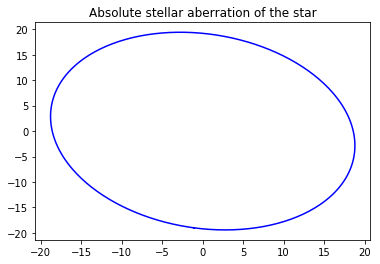

In [7]:
plt.plot((raAbsAbStar - raStar) * 3600 * np.cos(np.deg2rad(decAbsAbStar)), (decAbsAbStar - decStar) * 3600, "b", label = "From PlatoSim")
plt.title("Absolute stellar aberration of the star")

Text(0.5, 1.0, 'Absolute stellar aberration of the platform')

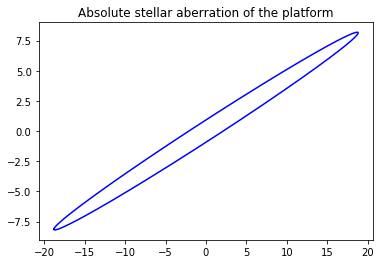

In [8]:
plt.plot((raAbsAbPlatform - raPlatform) * 3600 * np.cos(np.deg2rad(decAbsAbPlatform)), (decAbsAbPlatform - decPlatform) * 3600, "b", label = "From PlatoSim")
plt.title("Absolute stellar aberration of the platform")

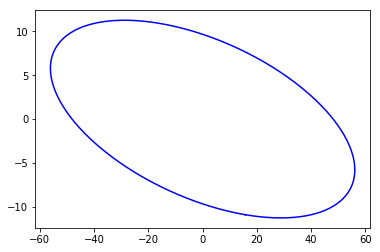

In [13]:
raDiffAb = (raAbsAbStar - raStar) * 3600 - (raAbsAbPlatform - raPlatform) * 3600
decDiffAb = (decAbsAbStar - decStar) * 3600 - (decAbsAbPlatform - decPlatform) * 3600

plt.plot(raDiffAb, decDiffAb, "b")

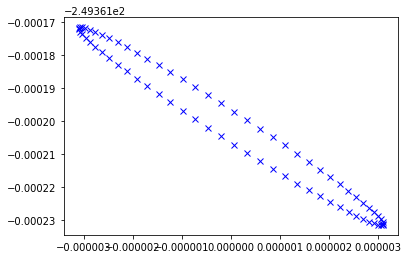

In [11]:
plt.plot(raDiffAbStar - raStar, decDiffAbStar - raStar, "bx")

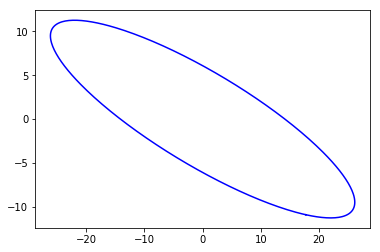

In [17]:
aberrStarRa = (raAbsAbStar - raStar) * 3600 * np.cos(np.deg2rad(decAbsAbStar))
aberrStarDec = (decAbsAbStar - decStar) * 3600

aberrPlatformRa = (raAbsAbPlatform - raPlatform) * 3600 * np.cos(np.deg2rad(decAbsAbPlatform))
aberrPlatformDec = (decAbsAbPlatform - decPlatform) * 3600

plt.plot(aberrStarRa - aberrPlatformRa, aberrStarDec - aberrPlatformDec, "b")